# Quick SARIMAX Check
Minimal notebook to test `sarimax_train` on hourly data.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.wait_time_forecasting.paths import notebook_context
from modeling.wait_time_forecasting.data_preparation import prepare_train_df
from modeling.wait_time_forecasting.sarimax import sarimax_train

ctx = notebook_context(project_root=PROJECT_ROOT)
PROJECT_ROOT = ctx["project_root"]
DATA_DIR = ctx["data_dir"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code
DATA_DIR: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\modeling\data\raw


In [ ]:
pack = prepare_train_df(data_dir=DATA_DIR, train_ratio=0.8)
train_df = pack['train_df']
test_df = pack['test_df']

attraction_name = str(train_df['ENTITY_DESCRIPTION_SHORT'].iloc[0])
print('train rows:', len(train_df))
print('test rows:', len(test_df))
print('split timestamp:', pack['split_timestamp'])

train rows: 238769
test rows: 55367
split timestamp: 2021-12-12 20:00:00


In [3]:
trained = sarimax_train(
    train_df,
    attraction_name,
    # optional: order_grid=[(0, 0, 1), (1, 0, 1), (1, 1, 1), (2, 1, 2)],
    search_maxiter=30,
    show_progress=True,
)

res = trained["model"]
exog_cols = trained["exog_cols"]

print("selected order:", trained["order"])
print("best AIC from search:", trained["best_aic"])
print("num exog cols:", len(exog_cols))
print("model AIC:", float(res.aic))
print("model BIC:", float(res.bic))


Order search [Bumper Cars]: [------------------------]   0% (0/18)

Order search [Bumper Cars]: [#-----------------------]   5% (1/18)

c:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order search [Bumper Cars]: [##----------------------]  11% (2/18)

c:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

Order search [Bumper Cars]: [#################-------]  72% (13/18)

c:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order search [Bumper Cars]: [######################--]  94% (17/18)

c:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order search [Bumper Cars]: [########################] 100% (18/18)
Selected order for Bumper Cars: (2, 0, 1) (AIC=62703.467)
Using cached best model from order search (no second fit).
selected order: (2, 0, 1)
best AIC from search: 62703.467162730485
num exog cols: 28
model AIC: 62703.467162730485
model BIC: 62935.938646116294


In [9]:
test_attr = test_df[test_df["ENTITY_DESCRIPTION_SHORT"].astype(str).eq(attraction_name)].copy()
test_attr = test_attr.sort_values("date_hour").reset_index(drop=True)

if test_attr.empty:
    raise ValueError("No test rows for selected attraction.")

y_true = pd.to_numeric(test_attr["wait_time_avg"], errors="coerce").reset_index(drop=True)

if exog_cols:
    X_test = test_attr.reindex(columns=exog_cols).apply(pd.to_numeric, errors="coerce")
    for c in X_test.columns:
        non_na = X_test[c].dropna()
        fill_value = float(non_na.median()) if not non_na.empty else 0.0
        X_test[c] = X_test[c].fillna(fill_value)
else:
    X_test = None

pred = res.get_forecast(steps=len(test_attr), exog=X_test).predicted_mean
y_pred = pd.Series(pred).reset_index(drop=True)

mask = y_true.notna() & y_pred.notna()
if not mask.any():
    raise ValueError("No valid y_true/y_pred pairs after alignment.")

err = y_true[mask].to_numpy() - y_pred[mask].to_numpy()
mae = float(np.mean(np.abs(err)))
rmse = float(np.sqrt(np.mean(err ** 2)))

print("test rows for attraction:", len(test_attr))
print("valid eval rows:", int(mask.sum()))
print("MAE:", mae)
print("RMSE:", rmse)


test rows for attraction: 2908
valid eval rows: 2908
MAE: 5.619329070655316
RMSE: 6.834146967309633


In [15]:
pred_df = pd.DataFrame(
    {
        "date_hour": test_attr["date_hour"].reset_index(drop=True),
        "y_true": y_true.reset_index(drop=True),
        "y_pred": y_pred.reset_index(drop=True),
    }
)

pred_df["abs_error"] = (pred_df["y_true"] - pred_df["y_pred"]).abs()
pred_df["sq_error"] = (pred_df["y_true"] - pred_df["y_pred"]) ** 2

pred_df.head()


,date_hour,y_true,y_pred,abs_error,sq_error
0,2021-12-12 21:00:00,5.00,5.795919,0.795919,0.633487
1,2021-12-13 09:00:00,2.50,7.291814,4.791814,22.961479
2,2021-12-13 10:00:00,6.25,11.653941,5.403941,29.202576
3,2021-12-13 11:00:00,21.25,13.212648,8.037352,64.599032
4,2021-12-13 12:00:00,12.50,13.794721,1.294721,1.676303


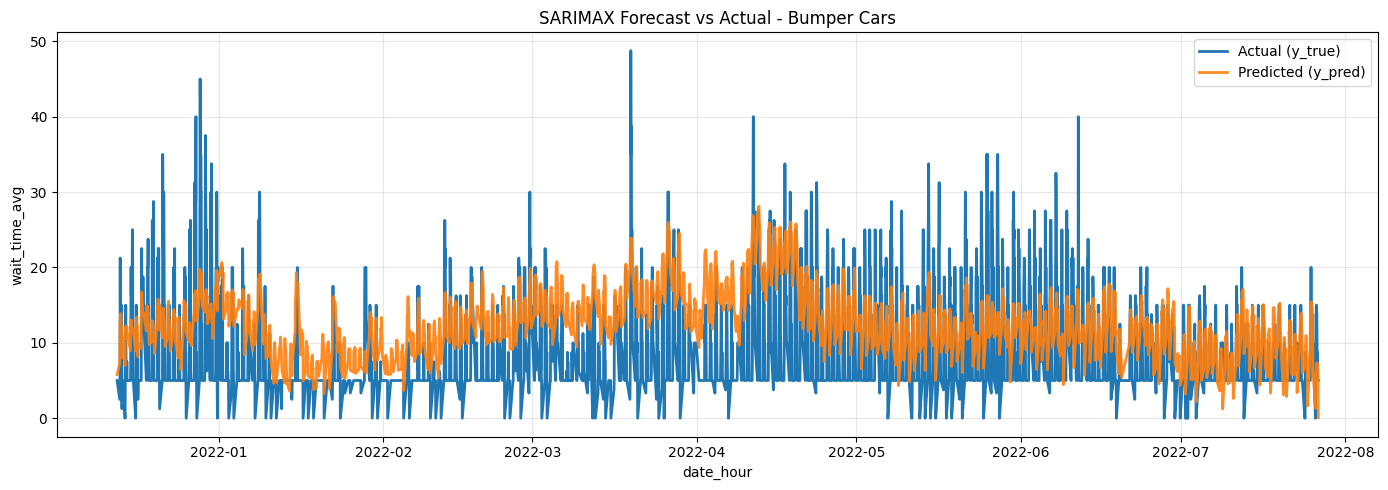

In [ ]:
plot_df = pred_df.copy()
plot_df["date_hour"] = pd.to_datetime(plot_df["date_hour"], errors="coerce")
plot_df = plot_df.sort_values("date_hour")

plt.figure(figsize=(14, 5))
plt.plot(plot_df["date_hour"], plot_df["y_true"], label="Actual (y_true)", linewidth=2)
plt.plot(plot_df["date_hour"], plot_df["y_pred"], label="Predicted (y_pred)", linewidth=2, alpha=0.9)

plt.title(f"SARIMAX Forecast vs Actual - {attraction_name}")
plt.xlabel("date_hour")
plt.ylabel("wait_time_avg")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7 steps ahead

In [ ]:
# attraction subset
test_attr = (
    test_df[test_df["ENTITY_DESCRIPTION_SHORT"].astype(str).eq(attraction_name)]
    .sort_values("date_hour")
    .copy()
)

if test_attr.empty:
    raise ValueError("No test rows for selected attraction.")

# 7-day window by DATE (not fixed 24*7 rows)
test_attr["date_hour"] = pd.to_datetime(test_attr["date_hour"], errors="coerce")
test_attr["date_day"] = test_attr["date_hour"].dt.floor("D")

start_day = test_attr["date_day"].min()
end_day_excl = start_day + pd.Timedelta(days=7)

test_7d = test_attr[(test_attr["date_day"] >= start_day) & (test_attr["date_day"] < end_day_excl)].reset_index(drop=True)

steps = len(test_7d)
if steps == 0:
    raise ValueError("No rows in the selected 7-day window.")

# exogenous for those exact rows
if exog_cols:
    X_test_7d = test_7d.reindex(columns=exog_cols).apply(pd.to_numeric, errors="coerce")
    for c in X_test_7d.columns:
        non_na = X_test_7d[c].dropna()
        fill_value = float(non_na.median()) if not non_na.empty else 0.0
        X_test_7d[c] = X_test_7d[c].fillna(fill_value)
else:
    X_test_7d = None

# forecast + metrics
y_pred_7d = res.get_forecast(steps=steps, exog=X_test_7d).predicted_mean.reset_index(drop=True)
y_true_7d = pd.to_numeric(test_7d["wait_time_avg"], errors="coerce").reset_index(drop=True)

mask = y_true_7d.notna() & y_pred_7d.notna()
err = y_true_7d[mask].to_numpy() - y_pred_7d[mask].to_numpy()

mae_7d = float(np.mean(np.abs(err)))
rmse_7d = float(np.sqrt(np.mean(err**2)))

print("Window:", start_day.date(), "to", (end_day_excl - pd.Timedelta(days=1)).date())
print("Rows used:", steps)
print("MAE 7d:", mae_7d)
print("RMSE 7d:", rmse_7d)


Window: 2021-12-12 to 2021-12-18
Rows used: 85
MAE 7d: 4.54082941735947
RMSE 7d: 5.325924516026993


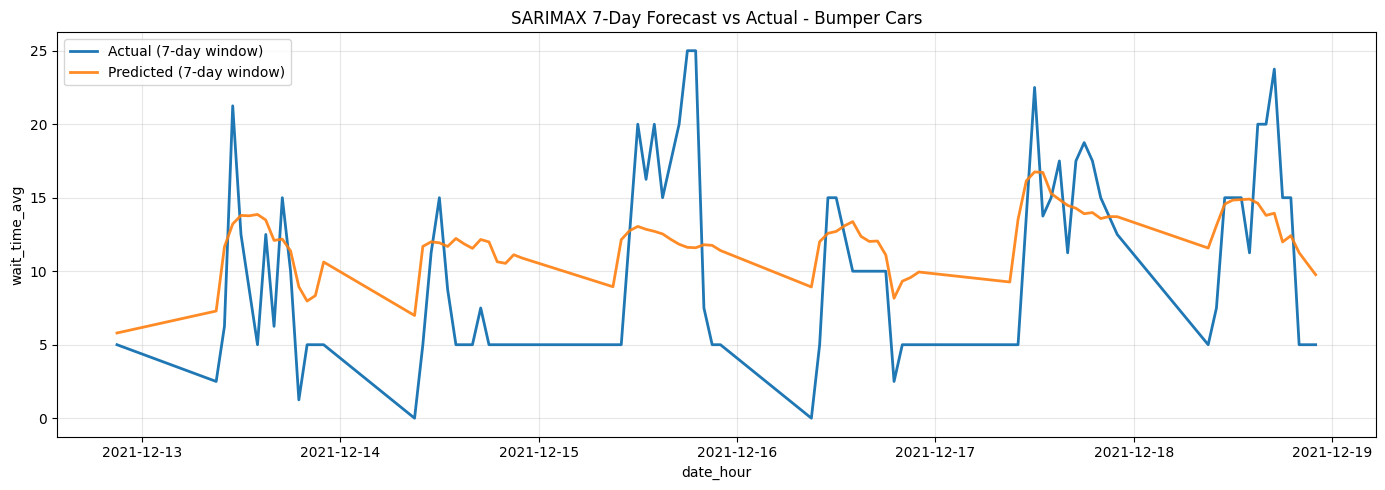

In [18]:
plot_7d = pd.DataFrame(
    {
        "date_hour": test_7d["date_hour"].reset_index(drop=True),
        "y_true": y_true_7d.reset_index(drop=True),
        "y_pred": y_pred_7d.reset_index(drop=True),
    }
).sort_values("date_hour")

plt.figure(figsize=(14, 5))
plt.plot(plot_7d["date_hour"], plot_7d["y_true"], label="Actual (7-day window)", linewidth=2)
plt.plot(plot_7d["date_hour"], plot_7d["y_pred"], label="Predicted (7-day window)", linewidth=2, alpha=0.9)

plt.title(f"SARIMAX 7-Day Forecast vs Actual - {attraction_name}")
plt.xlabel("date_hour")
plt.ylabel("wait_time_avg")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
